# 01 — Baselines: Seasonal Naive & Bayesian Structural Time Series

**Project:** Bayesian GP decomposition of Norwegian live births 1966–2025  

This notebook implements and evaluates the two baseline models:

1. **Seasonal naive** — $\hat y_t = y_{t-12}$ (deterministic)
2. **Bayesian structural time series (BSTS)** — local-linear-trend at year level + fixed monthly seasonal effects, Gaussian likelihood on log births, inferred with SVI in Pyro

Hold-out evaluation: **2025-01 to 2025-12** (12 months of already-observed ground truth).  
Training set: **1966-01 to 2024-12** (708 monthly observations).

The processed long-form dataset (`norway_births_monthly.csv`) is also saved here for downstream notebooks.

## 0. Imports

In [136]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import ClippedAdam
import pyro.infer.autoguide as autoguide
from scipy.stats import norm as scipy_norm

pyro.set_rng_seed(2026)
torch.manual_seed(2026)

PROJ = Path(".")  # run notebook from its own directory
print("Pyro", pyro.__version__, "| Torch", torch.__version__)

Pyro 1.9.1 | Torch 2.8.0


## 1. Data loading & preprocessing

In [137]:
def load_ssb_births(path: Path) -> pd.DataFrame:
    """Reshape SSB table 05531 from wide to long form."""
    df_raw = pd.read_csv(path, sep=";", encoding="latin-1", skiprows=1, index_col=0)
    abs_cols = [c for c in df_raw.columns if "absolutte tall" in c]
    df = df_raw[abs_cols].copy()
    df.columns = [int(c.split()[0]) for c in df.columns]
    month_map = {
        "januar": 1, "februar": 2, "mars": 3, "april": 4,
        "mai": 5, "juni": 6, "juli": 7, "august": 8,
        "september": 9, "oktober": 10, "november": 11, "desember": 12,
    }
    df.index = df.index.map(month_map)
    df.index.name = "month"
    df_long = (
        df.reset_index()
        .melt(id_vars="month", var_name="year", value_name="births")
        .sort_values(["year", "month"])
        .reset_index(drop=True)
    )
    df_long["date"] = pd.to_datetime(
        df_long["year"].astype(str) + "-" + df_long["month"].astype(str).str.zfill(2) + "-15"
    )
    df_long["t"] = df_long["year"] + (df_long["month"] - 1) / 12.0  # decimal year
    df_long["year_idx"] = df_long["year"] - 1966           # 0 = 1966
    df_long["month_idx"] = df_long["month"] - 1            # 0 = January
    df_long["log_births"] = np.log(df_long["births"].astype(float))
    return df_long


SSB_CSV = PROJ / "05531_20260420-195045.csv"
df = load_ssb_births(SSB_CSV)

# Save processed dataset for downstream notebooks
out_csv = PROJ / "norway_births_monthly.csv"
df.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")
print(df.head())
print(f"\n{len(df)} observations | births range: {df.births.min()}–{df.births.max()}")

Saved → norway_births_monthly.csv
   month  year  births       date            t year_idx  month_idx  log_births
0      1  1966    5633 1966-01-15       1966.0        0          0    8.636397
1      2  1966    5047 1966-02-15  1966.083333        0          1    8.526549
2      3  1966    6207 1966-03-15  1966.166667        0          2    8.733433
3      4  1966    6390 1966-04-15      1966.25        0          3    8.762490
4      5  1966    6110 1966-05-15  1966.333333        0          4    8.717682

720 observations | births range: 3420–6390


In [138]:
# Train / test split
train = df[df["year"] <= 2024].copy().reset_index(drop=True)
test = df[df["year"] == 2025].copy().reset_index(drop=True)

print(f"Train: {len(train)} months ({train.year.min()}–{train.year.max()})")
print(f"Test : {len(test)} months ({test.year.min()})")

Train: 708 months (1966–2024)
Test : 12 months (2025)


In [139]:
N_TRAIN_YEARS  = int(train["year"].nunique())  # 59
_N_YEARS = N_TRAIN_YEARS  

In [140]:
# compute scaling factors for log_births (for standardization)
LOG_MEAN = train["log_births"].mean()
LOG_STD = train["log_births"].std()

print(f"Original Log Mean: {LOG_MEAN:.4f}, Std: {LOG_STD:.4f}")

# standardising such that log_births has mean 0 and std 1 in the training set
z_scores = (train["log_births"] - LOG_MEAN) / LOG_STD

# Convert to PyTorch tensors
year_idx_tr  = torch.tensor(train["year_idx"].values.astype("int64"),  dtype=torch.long)
month_idx_tr = torch.tensor(train["month_idx"].values.astype("int64"), dtype=torch.long)

# Standardized log_births as target variable
log_y_tr = torch.tensor(z_scores.values.astype("float32"), dtype=torch.float32)

print(f"log_y_tr.mean() = {log_y_tr.mean():.4f}")

Original Log Mean: 8.4733, Std: 0.1086
log_y_tr.mean() = -0.0000


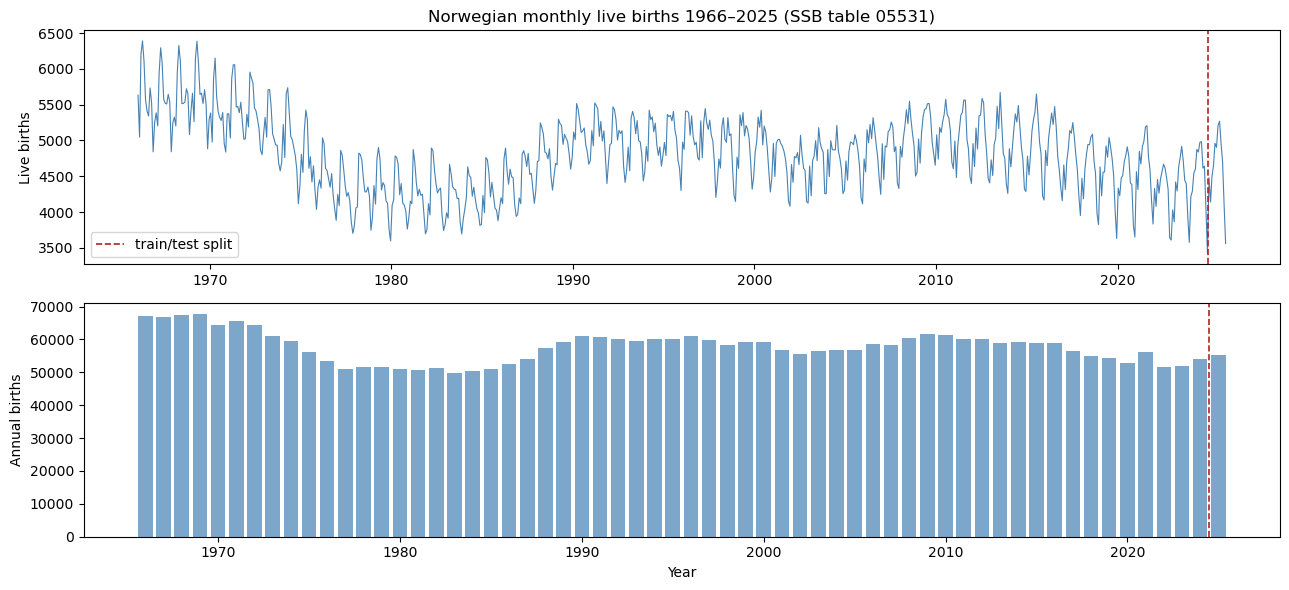

In [141]:
# Overview plot
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(df["date"], df["births"], lw=0.8, color="steelblue")
axes[0].axvline(pd.Timestamp("2025-01-01"), color="firebrick", ls="--", lw=1.2, label="train/test split")
axes[0].set_ylabel("Live births")
axes[0].set_title("Norwegian monthly live births 1966–2025 (SSB table 05531)")
axes[0].legend()

annual = df.groupby("year")["births"].sum()
axes[1].bar(annual.index, annual.values, width=0.8, color="steelblue", alpha=0.7)
axes[1].axvline(2024.5, color="firebrick", ls="--", lw=1.2)
axes[1].set_ylabel("Annual births")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig(PROJ / "01_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Baseline 1 — Seasonal naive

Point forecast: $\hat y_t = y_{t-12}$ (same month, prior year).  
Probabilistic version: fit a Normal distribution to the 5-year average and std of same-month values to get prediction intervals.

In [142]:
def seasonal_naive_forecast(train: pd.DataFrame, test: pd.DataFrame, k_years: int = 5):
    """
    For each test month, estimate mean and std from the last k_years of the same month in train.
    Returns a DataFrame with columns: month, point, mu, sigma.
    """
    rows = []
    for _, row in test.iterrows():
        m = row["month"]
        recent = train[(train["month"] == m) & (train["year"] >= row["year"] - k_years)]["births"].values
        mu    = float(np.mean(recent))
        sigma = float(np.std(recent, ddof=1)) if len(recent) > 1 else mu * 0.03
        rows.append({"month": m, "year": int(row["year"]), "point": recent[-1],  # y_{t-12}
                     "mu": mu, "sigma": sigma, "actual": int(row["births"])})
    return pd.DataFrame(rows)


sn_pred = seasonal_naive_forecast(train, test, k_years=5)
print(sn_pred.to_string(index=False))

 month  year  point     mu      sigma  actual
     1  2025   4214 4293.8 194.333991    4479
     2  2025   4293 4156.0 187.265854    4141
     3  2025   4542 4548.2 173.897096    4494
     4  2025   4599 4467.6 181.676361    4650
     5  2025   4875 4716.4 186.098898    4961
     6  2025   4838 4788.8 153.424900    4904
     7  2025   4974 4931.8 185.494474    5206
     8  2025   4984 4859.8 236.516807    5269
     9  2025   4612 4540.8 148.236972    4952
    10  2025   4641 4466.8 141.937310    4696
    11  2025   4021 3915.0 198.752358    4089
    12  2025   3420 3617.4 148.158024    3560


## 3. Baseline 2 — Bayesian Structural Time Series (BSTS)

**Model (on log-births scale)**

$$
\log y_i \sim \mathcal{N}(\underbrace{\lambda_{\text{year}(i)}}_\text{local level} + \underbrace{\gamma_{\text{month}(i)}}_\text{seasonal},\; \sigma_\text{obs}^2)
$$

**Local-linear trend at year level** (59 years of training):
$$
\lambda_0 \sim \mathcal{N}(\bar{\mu}, 0.5), \quad
\nu_0 \sim \mathcal{N}(0, 0.02)
$$
$$
\nu_t = \nu_{t-1} + w_\nu,\; w_\nu \sim \mathcal{N}(0, \sigma_\nu)
$$
$$
\lambda_t = \lambda_{t-1} + \nu_{t-1} + w_\lambda,\; w_\lambda \sim \mathcal{N}(0, \sigma_\lambda)
$$

**Fixed monthly seasonals** (sum-to-zero constraint, 11 free parameters):
$$
\gamma_m \sim \mathcal{N}(0, 0.1),\; m=1,\ldots,11, \quad \gamma_{12} = -\sum_{m=1}^{11}\gamma_m
$$

Inference: **SVI** with `AutoNormal` guide, `ClippedAdam` optimiser.

In [143]:
def bsts_model_simple(year_idx, month_idx, log_y=None):
        sigma_level = pyro.sample("sigma_level", dist.HalfNormal(0.1))
        sigma_obs   = pyro.sample("sigma_obs",   dist.HalfNormal(0.1))

        seasonal_raw = pyro.sample(
            "seasonal_raw", dist.Normal(torch.zeros(11), torch.full((11,), 0.5)).to_event(1)
        )
        seasonal = torch.cat([seasonal_raw, -seasonal_raw.sum().unsqueeze(0)])

        level0 = pyro.sample("level0", dist.Normal(0.0, 1.0))
        
        level_noise = pyro.sample(
            "level_noise",
            dist.Normal(torch.zeros(_N_YEARS - 1), sigma_level.expand(_N_YEARS - 1)).to_event(1),
        )

        level_noise_cs = torch.cat([torch.zeros(1), level_noise.cumsum(-1)])
        levels = level0 + level_noise_cs

        mu = levels[year_idx] + seasonal[month_idx]
        with pyro.plate("data", len(year_idx)):
            pyro.sample("obs", dist.Normal(mu, sigma_obs), obs=log_y)

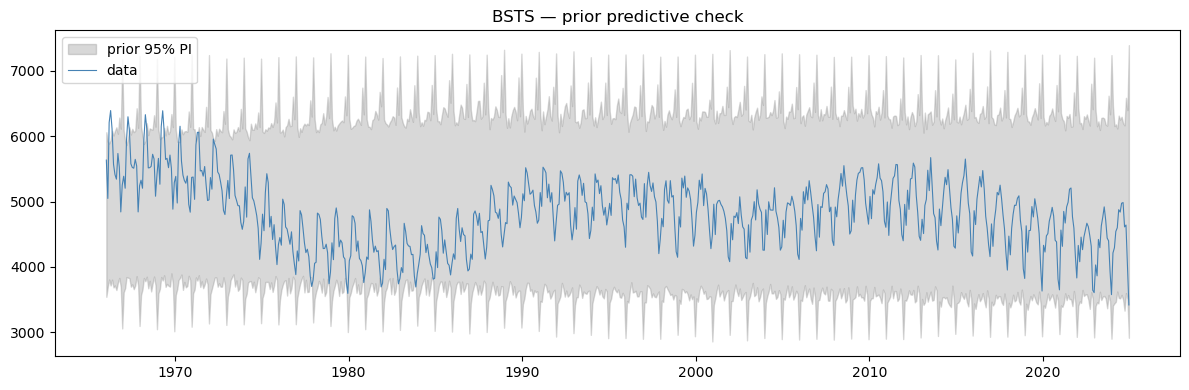

In [144]:
# Prior predictive check
prior_pred = Predictive(bsts_model_simple, num_samples=200)(year_idx_tr, month_idx_tr)
z_prior_obs = prior_pred["obs"].numpy()  # (200, 708) in Z-scale

# Transform back to log-scale, then to actual births
prior_obs = np.exp((z_prior_obs * LOG_STD) + LOG_MEAN)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(
    train["date"],
    np.percentile(prior_obs, 2.5, axis=0),
    np.percentile(prior_obs, 97.5, axis=0),
    alpha=0.3, color="grey", label="prior 95% PI",
)
ax.plot(train["date"], train["births"], color="steelblue", lw=0.8, label="data")
ax.set_title("BSTS — prior predictive check")
ax.legend()
plt.tight_layout()
plt.show()

step     0  ELBO = -1363.7
step   500  ELBO = -719.1
step  1000  ELBO = -659.4
step  1500  ELBO = -491.7
step  2000  ELBO = -553.5
step  2500  ELBO = -632.2
step  3000  ELBO = -474.3
step  3500  ELBO = -462.1
step  4000  ELBO = -473.0
step  4500  ELBO = -670.7


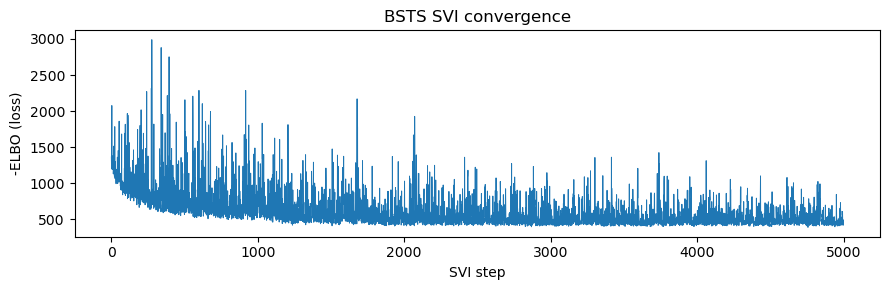

In [145]:
# SVI training
pyro.clear_param_store()

guide = autoguide.AutoNormal(bsts_model_simple)
optimizer = ClippedAdam({"lr": 0.01, "clip_norm": 10.0})
svi = SVI(bsts_model_simple, guide, optimizer, loss=Trace_ELBO())

N_STEPS = 5000
losses = []
for step in range(N_STEPS):
    loss = svi.step(year_idx_tr, month_idx_tr, log_y_tr)
    losses.append(loss)
    if step % 500 == 0:
        print(f"step {step:5d}  ELBO = {-loss:.1f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(losses, lw=0.7)
ax.set_xlabel("SVI step")
ax.set_ylabel("-ELBO (loss)")
ax.set_title("BSTS SVI convergence")
plt.tight_layout()
plt.savefig(PROJ / "01_bsts_svi_loss.png", dpi=120, bbox_inches="tight")
plt.show()

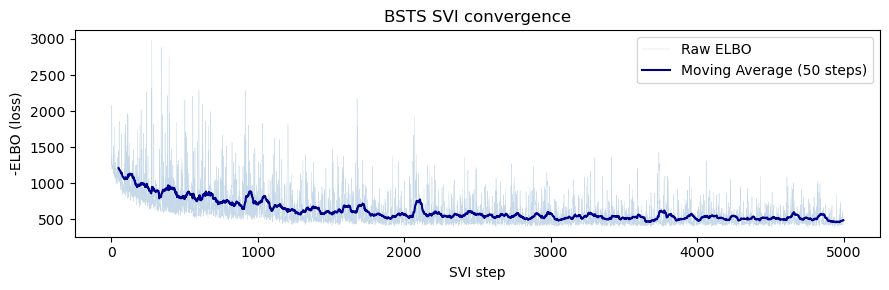

In [146]:
# computing a moving average to smooth the SVI loss curve
window = 50
smoothed_losses = pd.Series(losses).rolling(window=window).mean()

fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(losses, lw=0.3, color="steelblue", alpha=0.3, label="Raw ELBO")

ax.plot(smoothed_losses, lw=1.5, color="darkblue", label=f"Moving Average ({window} steps)")

ax.set_xlabel("SVI step")
ax.set_ylabel("-ELBO (loss)")
ax.set_title("BSTS SVI convergence")
ax.legend()
plt.tight_layout()
plt.show()

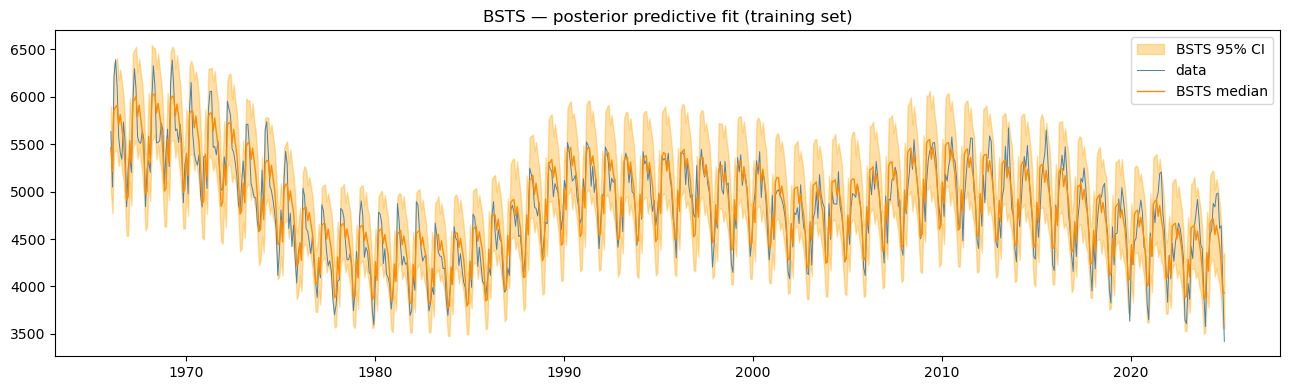

In [147]:
# Posterior predictive on training set
N_SAMPLES = 1000
post_pred_tr = Predictive(bsts_model_simple, guide=guide, num_samples=N_SAMPLES)(
    year_idx_tr, month_idx_tr
)


# Transform from Z-scale -> Log-scale -> Actual births
z_post_obs = post_pred_tr["obs"].numpy()
obs_tr = np.exp((z_post_obs * LOG_STD) + LOG_MEAN)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(
    train["date"],
    np.percentile(obs_tr, 2.5, axis=0),
    np.percentile(obs_tr, 97.5, axis=0),
    alpha=0.35, color="orange", label="BSTS 95% CI",
)
ax.plot(train["date"], train["births"], color="steelblue", lw=0.7, label="data")
ax.plot(train["date"], np.median(obs_tr, axis=0), color="darkorange", lw=1.0, label="BSTS median")
ax.set_title("BSTS — posterior predictive fit (training set)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Forecasting 2025

To forecast 2025, we propagate the local-linear-trend one year beyond the training window:
$$
\nu_{59} = \nu_{58} + w_\nu, \quad
\lambda_{59} = \lambda_{58} + \nu_{58} + w_\lambda
$$
then predict each month via $\log y_{2025,m} \sim \mathcal{N}(\lambda_{59} + \gamma_m, \sigma_\text{obs})$.

In [148]:
def get_posterior_samples(guide, num_samples=N_SAMPLES):
    """Draw samples from the variational posterior."""
    return {k: v.detach() for k, v in
            Predictive(bsts_model_simple, guide=guide, num_samples=num_samples,
                       return_sites=["level0", "level_noise", "seasonal_raw",
                                     "sigma_level", "sigma_obs"])(
                year_idx_tr, month_idx_tr).items()}


def forecast_2025_samples(samples, n_train_years=N_TRAIN_YEARS):
    """
    Propagate posterior samples one year ahead to forecast 2025.
    Returns tensor of shape (S, 12) with Z-score forecasts.
    """
    S   = samples["level0"].shape[0]
    n   = n_train_years                     # 59

    # Flatten shapes
    level0  = samples["level0"].float().reshape(S)
    level_n = samples["level_noise"].float().reshape(S, n - 1)   # (S, 58)
    s_raw   = samples["seasonal_raw"].float().reshape(S, 11)     # (S, 11)
    sig_lev = samples["sigma_level"].float().reshape(S)
    sig_obs = samples["sigma_obs"].float().reshape(S)

    assert level_n.shape == (S, n - 1), f"level_n shape {level_n.shape}"

    # Seasonal effects (S, 12)
    s12 = torch.zeros(S, 12)
    s12[:, :11] = s_raw
    s12[:, 11]  = -s_raw.sum(dim=1)

    # Last-year state (End of 2024)
    lev_last = level0 + level_n.sum(dim=1)

    # Propagate one year (2025)
    lev_2025 = lev_last + torch.randn(S) * sig_lev

    # Monthly forecasts 
    z_fore = lev_2025.unsqueeze(1) + s12 + torch.randn(S, 12) * sig_obs.unsqueeze(1)
    return z_fore   # (S, 12)


torch.manual_seed(2026)
post_samples  = get_posterior_samples(guide, num_samples=N_SAMPLES)

# Generating predictions on Z-scale
z_fore_2025 = forecast_2025_samples(post_samples)

# (Z-score -> Log-scale)
log_fore_2025 = (z_fore_2025 * LOG_STD) + LOG_MEAN

# Convert to actual births
fore_2025 = torch.exp(log_fore_2025).numpy()

bsts_pred = pd.DataFrame({
    "month":  np.arange(1, 13),
    "year":   2025,
    "point":  np.median(fore_2025, axis=0),
    "lo80":   np.percentile(fore_2025, 10,  axis=0),
    "hi80":   np.percentile(fore_2025, 90,  axis=0),
    "lo95":   np.percentile(fore_2025, 2.5, axis=0),
    "hi95":   np.percentile(fore_2025, 97.5, axis=0),
    "actual": test["births"].values,
})
print(bsts_pred.to_string(index=False))

 month  year       point        lo80        hi80        lo95        hi95  actual
     1  2025 4362.199219 4072.506836 4663.930664 3914.046143 4814.815918    4479
     2  2025 4159.189453 3890.135254 4487.143555 3717.893799 4616.167480    4141
     3  2025 4693.098633 4363.730469 5041.774902 4201.767090 5220.213867    4494
     4  2025 4717.585938 4394.291992 5036.141113 4243.548340 5221.110840    4650
     5  2025 4712.392578 4408.317383 5070.442383 4249.543945 5261.020996    4961
     6  2025 4563.737305 4244.096680 4913.677734 4095.169189 5075.669922    4904
     7  2025 4645.915527 4341.716797 5004.448730 4171.213867 5196.933105    5206
     8  2025 4535.759766 4222.720703 4874.509277 4088.442627 5048.172852    5269
     9  2025 4436.942383 4149.295898 4762.950684 3992.708740 4920.235352    4952
    10  2025 4242.490234 3961.186035 4530.889160 3819.872803 4689.054688    4696
    11  2025 3923.106689 3647.015869 4212.620117 3519.712646 4366.700195    4089
    12  2025 3956.088135 368

## 5. Evaluation metrics

| Metric | Description |
|--------|-------------|
| RMSE | root-mean-squared error on counts |
| MAE | mean absolute error on counts |
| CRPS | continuous ranked probability score (lower = better) |
| Cov80 | empirical 80% predictive-interval coverage |
| Cov95 | empirical 95% predictive-interval coverage |
| LPD | log predictive density (higher = better) |

In [149]:
def crps_samples(y_true: np.ndarray, samples: np.ndarray) -> float:
    """Energy-form CRPS. samples: (S, N), y_true: (N,)"""
    term1 = np.mean(np.abs(samples - y_true[np.newaxis, :]), axis=0)
    perm  = np.random.permutation(samples.shape[0])
    term2 = 0.5 * np.mean(np.abs(samples - samples[perm, :]), axis=0)
    return float(np.mean(term1 - term2))


def crps_normal(y_true: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    z = (y_true - mu) / sigma
    c = sigma * (z * (2 * scipy_norm.cdf(z) - 1) + 2 * scipy_norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(c))


def lpd_normal(y_true: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    return float(np.mean(scipy_norm.logpdf(y_true, loc=mu, scale=sigma)))


def lpd_samples(y_true: np.ndarray, samples: np.ndarray, bw_frac: float = 0.1) -> float:
    from scipy.stats import gaussian_kde
    lpds = []
    for i, y in enumerate(y_true):
        kde = gaussian_kde(samples[:, i], bw_method=bw_frac)
        lpds.append(float(np.log(kde(y) + 1e-300)))
    return float(np.mean(lpds))


def evaluate(name, actual, point, lo80, hi80, lo95, hi95,
             samples=None, mu=None, sigma=None):
    actual = np.asarray(actual, dtype=float)
    point  = np.asarray(point,  dtype=float)
    rmse   = float(np.sqrt(np.mean((point - actual) ** 2)))
    mae    = float(np.mean(np.abs(point - actual)))
    cov80  = float(np.mean((actual >= lo80) & (actual <= hi80)))
    cov95  = float(np.mean((actual >= lo95) & (actual <= hi95)))
    if samples is not None:
        # samples must be (S, N)
        assert samples.shape[1] == len(actual), \
            f"samples shape {samples.shape} vs actual len {len(actual)} — need (S, N)"
        crps = crps_samples(actual, samples)
        lpd  = lpd_samples(actual, samples)
    elif mu is not None:
        crps = crps_normal(actual, mu, sigma)
        lpd  = lpd_normal(actual, mu, sigma)
    else:
        crps = lpd = float("nan")
    return {"Model": name, "RMSE": rmse, "MAE": mae,
            "CRPS": crps, "Cov80": cov80, "Cov95": cov95, "LPD": lpd}


actual_2025 = test["births"].values.astype(float)

results = [
    evaluate(
        "Seasonal naive",
        actual_2025,
        sn_pred["point"].values,
        sn_pred["mu"].values - 1.28 * sn_pred["sigma"].values,
        sn_pred["mu"].values + 1.28 * sn_pred["sigma"].values,
        sn_pred["mu"].values - 1.96 * sn_pred["sigma"].values,
        sn_pred["mu"].values + 1.96 * sn_pred["sigma"].values,
        mu=sn_pred["mu"].values, sigma=sn_pred["sigma"].values,
    ),
    evaluate(
        "BSTS (SVI)",
        actual_2025,
        bsts_pred["point"].values,
        bsts_pred["lo80"].values,
        bsts_pred["hi80"].values,
        bsts_pred["lo95"].values,
        bsts_pred["hi95"].values,
        samples=fore_2025,   # (S=1000, N=12)
    ),
]

results_df = pd.DataFrame(results).set_index("Model")
results_df[["RMSE", "MAE", "CRPS"]] = results_df[["RMSE", "MAE", "CRPS"]].round(1)
results_df[["Cov80", "Cov95"]]      = results_df[["Cov80", "Cov95"]].round(2)
results_df["LPD"]                    = results_df["LPD"].round(3)
print(results_df.to_string())

# save csv
results_df.to_csv(PROJ / "01_eval_baselines.csv")

print(f"\nSaved baselines to: {PROJ / '01_eval_baselines.csv'}")

                 RMSE    MAE   CRPS  Cov80  Cov95    LPD
Model                                                   
Seasonal naive  179.8  149.0  136.0   0.58   0.92 -6.953
BSTS (SVI)      381.1  317.9  227.9   0.58   0.67 -7.639

Saved baselines to: 01_eval_baselines.csv


/var/folders/8_/4js4c46925s2xtwqlrvkljlm0000gn/T/ipykernel_30940/2465647625.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lpds.append(float(np.log(kde(y) + 1e-300)))


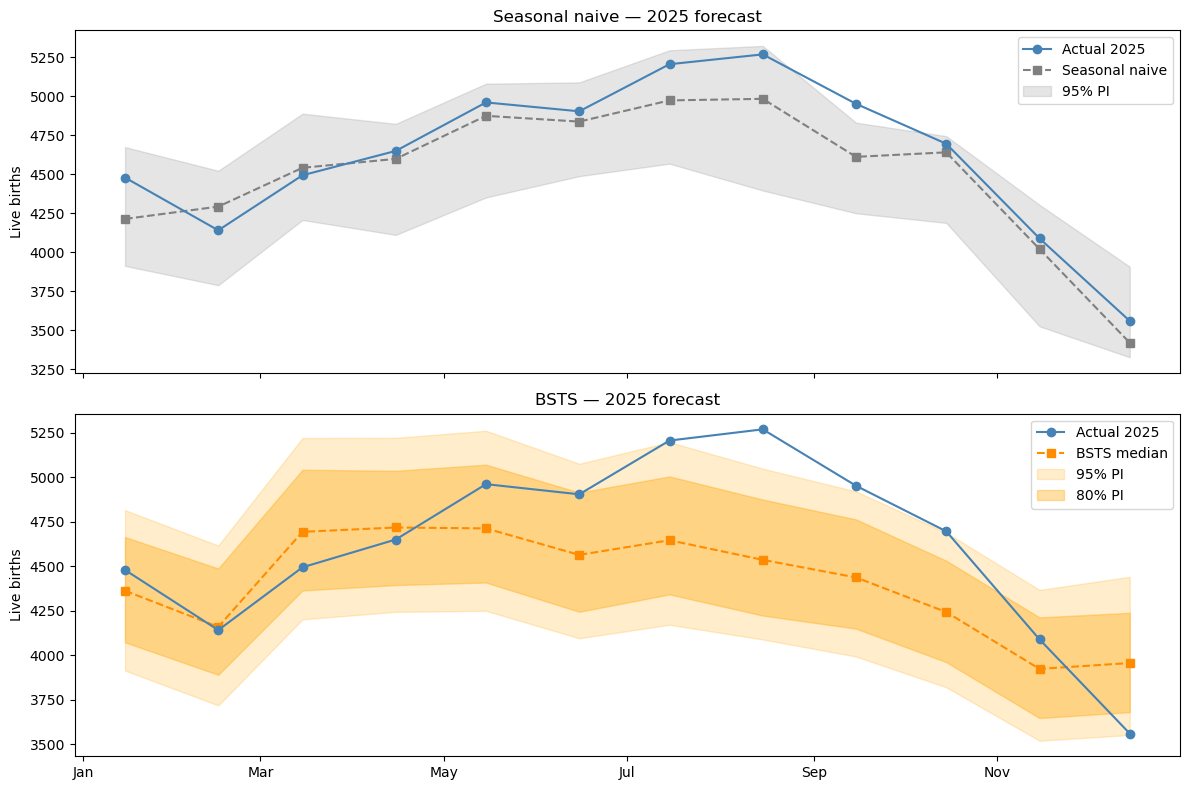

In [150]:
# Forecast comparison plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

months_2025 = test["date"].values

# --- panel 1: seasonal naive ---
ax = axes[0]
ax.plot(months_2025, actual_2025, "o-", color="steelblue", label="Actual 2025", zorder=5)
ax.plot(months_2025, sn_pred["point"].values, "s--", color="grey", label="Seasonal naive", zorder=4)
ax.fill_between(
    months_2025,
    sn_pred["mu"] - 1.96 * sn_pred["sigma"],
    sn_pred["mu"] + 1.96 * sn_pred["sigma"],
    alpha=0.2, color="grey", label="95% PI",
)
ax.set_title("Seasonal naive — 2025 forecast")
ax.legend()
ax.set_ylabel("Live births")

# --- panel 2: BSTS ---
ax = axes[1]
ax.plot(months_2025, actual_2025, "o-", color="steelblue", label="Actual 2025", zorder=5)
ax.plot(months_2025, bsts_pred["point"].values, "s--", color="darkorange", label="BSTS median", zorder=4)
ax.fill_between(
    months_2025,
    bsts_pred["lo95"].values,
    bsts_pred["hi95"].values,
    alpha=0.2, color="orange", label="95% PI",
)
ax.fill_between(
    months_2025,
    bsts_pred["lo80"].values,
    bsts_pred["hi80"].values,
    alpha=0.35, color="orange", label="80% PI",
)
ax.set_title("BSTS — 2025 forecast")
ax.legend()
ax.set_ylabel("Live births")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.savefig(PROJ / "01_forecast_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Summary

These two baselines are the comparison targets for the GP decomposition model in `03_gp_svi.ipynb`, where the consolidated evaluation table (all models side-by-side) lives.

Key observations:
- The **seasonal naive** is a strong but purely mechanical baseline; it ignores any secular trend change between 2024 and 2025.
- The **BSTS** explicitly models the evolving trend, which should give better-calibrated uncertainty when the trend is changing direction.
- Both baselines use only the **annual seasonal structure** — neither captures multi-year cyclicality or shock recovery (the COVID dip), which is the job of the GP model.

Metric table saved to `01_eval_baselines.csv` for the consolidated comparison in notebook 03.